## Sistemas de Recomendación 2/2

### Estructura del notebook

Este notebook implementa y compara técnicas de **filtrado colaborativo** basadas en la librería `surprise`:

| Sección | Técnica | Tipo |
|---|---|---|
| 1 | SVD (Singular Value Decomposition) | Model-based, factorización matricial |
| 2 | KNNWithMeans | Memory-based, vecinos más cercanos |
| 3 | Comparativa completa | Accuracy, ranking, cobertura, velocidad |

> ⚠️ **Requisito**: `surprise` requiere `numpy < 2.0`. Instalar con:
> ```bash
> pip install 'numpy<2' scikit-surprise
> ```

In [7]:
### Ojo surprise SVD funciona con una version de numpy<2 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [9]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\08 Sistemas de recomendacion'

#### 0. Importamos los datos 

Data set obtenido de kaggle

https://www.kaggle.com/datasets/zygmunt/goodbooks-10k

There have been good datasets for movies (Netflix, Movielens) and music (Million Songs) recommendation, but not for books. That is, until now.

This dataset contains ratings for ten thousand popular books. As to the source, let's say that these ratings were found on the internet. Generally, there are 100 reviews for each book, although some have less - fewer - ratings. Ratings go from one to five.

Both book IDs and user IDs are contiguous. For books, they are 1-10000, for users, 1-53424. All users have made at least two ratings. Median number of ratings per user is 8.

There are also books marked to read by the users, book metadata (author, year, etc.) and tags.

In [2]:
ratings_data = pd.read_csv('./data/ratings.csv')
books_metadata = pd.read_csv('./data/books.csv')
ratings_data.head(10)

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4
5,1,2077,4
6,1,2487,4
7,1,2900,5
8,1,3662,4
9,1,3922,5


In [3]:
books_metadata.head(10)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


#### 1. Modelo SVD

**SVD (Singular Value Decomposition)** es el algoritmo que ganó el Netflix Prize en 2009 (implementación de Simon Funk).

La idea: descomponer la matriz usuario-libro en vectores latentes que capturan patrones ocultos (géneros, estilos, temáticas) sin necesidad de etiquetas explícitas.

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u$$

Donde $p_u$ son los factores latentes del usuario, $q_i$ los del libro, y $b_u$, $b_i$ son los sesgos (bias) de usuario e ítem.

> **Parámetros clave**: `n_factors` (dimensión del espacio latente, por defecto 100), `n_epochs` (iteraciones de SGD), `lr_all` (learning rate), `reg_all` (regularización).

### ¿Qué es Surprise?

`surprise` (Simple Python RecommendatIon System Engine) es una librería específica para sistemas de recomendación con filtrado colaborativo. Implementa algoritmos como SVD, KNN, NMF y otros, con utilidades de evaluación integradas (cross-validation, métricas de ranking).

Para usarla necesitamos convertir nuestro DataFrame a un objeto `Dataset` de Surprise, indicando la escala de ratings (1-5 en este caso).
- IDs de usuario  
- item IDs (el id de cada libreo)  
- Rating (en este caso de 1–5) 



In [4]:
from surprise import Dataset
from surprise import Reader
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_data[['user_id', 'book_id', 'rating']], reader)

#### 1.1 Training and Cross-Validating a Simple SVD Model

<!-- Usamos **5-fold cross-validation** para estimar la capacidad de generalización del modelo. -->

- **RMSE** (Root Mean Squared Error): penaliza errores grandes. Típicamente ~0.85-0.90 en este dataset.
- **MAE** (Mean Absolute Error): error medio en escala de estrellas. Más interpretable.

> Tras la cross-validation, entrenamos el modelo final sobre el 80% de los datos (`train_test_split` con `test_size=0.2`) para evaluar luego en la comparativa.

In [5]:
from surprise import SVD
from surprise.model_selection import cross_validate
svd = SVD(verbose=True, n_epochs=10) # por defecto emplea 100 factores latentes
cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Evaluating RMSE, MAE of algorithm SVD on 5 split(s

{'test_rmse': array([0.84915018, 0.84805753, 0.85073249, 0.85230861, 0.8526266 ]),
 'test_mae': array([0.66862294, 0.66753583, 0.66940066, 0.67043212, 0.67123255]),
 'fit_time': (56.75012922286987,
  55.57279920578003,
  57.80642509460449,
  68.5644862651825,
  60.71483826637268),
 'test_time': (11.752705335617065,
  11.628785133361816,
  23.898236751556396,
  14.882346868515015,
  11.691665887832642)}

In [6]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.2)
svd.fit(trainset)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9


#### 1.2 Genera recomendaciones para un usuario concreto y un item concreto



> **Correcto**: usar un `book_id` real, por ejemplo `svd.predict(uid=1101, iid=1)`. O usar `predict_review('título del libro', ...)` que hace el mapeo automáticamente.

In [8]:
svd.predict(uid=1101, iid=2)

Prediction(uid=1101, iid=2, r_ui=None, est=4.352873557532734, details={'was_impossible': False})

#### Funciones auxiliares y de recomendación

Definimos cuatro funciones reutilizables:

- **`get_book_id`**: fuzzy matching de título → `book_id` (tolera erratas con `difflib`)
- **`get_book_info`**: devuelve metadatos de un libro dado su ID
- **`predict_review`**: predice el rating que un usuario daría a un libro concreto
- **`generate_recommendation`**: devuelve el **primer** libro aleatorio con rating predicho ≥ umbral

> ⚠️ **Limitación de `generate_recommendation`**: recorre libros en orden aleatorio y para al primero que supera el umbral. No garantiza encontrar el mejor — solo el primero aceptable. Para el top-N usar `generate_top_recommendations`.

In [12]:
import difflib
import random

def get_book_id(book_title, metadata):
    
    """
    Gets the book ID for a book title based on the closest match in the metadata dataframe.
    """
    
    existing_titles = list(metadata['title'].values)
    closest_titles = difflib.get_close_matches(book_title, existing_titles)
    book_id = metadata[metadata['title'] == closest_titles[0]]['id'].values[0]
    return book_id

def get_book_info(book_id, metadata):
    
    """
    Returns some basic information about a book given the book id and the metadata dataframe.
    """
    
    book_info = metadata[metadata['id'] == book_id][['id', 'isbn', 
                                                    'authors', 'title', 'original_title']]
    return book_info.to_dict(orient='records')

def predict_review(user_id, book_title, model, metadata):
    
    """
    Predicts the review (on a scale of 1-5) that a user would assign to a specific book. 
    """
    
    book_id = get_book_id(book_title, metadata)
    review_prediction = model.predict(uid=user_id, iid=book_id)
    return review_prediction.est

def generate_recommendation(user_id, model, metadata, thresh=4):
    
    """
    Generates a book recommendation for a user based on a rating threshold. Only
    books with a predicted rating at or above the threshold will be recommended
    """
    
    book_titles = list(metadata['title'].values)
    random.shuffle(book_titles)
    
    for book_title in book_titles:
        rating = predict_review(user_id, book_title, model, metadata)
        if rating >= thresh:
            book_id = get_book_id(book_title, metadata)
            return get_book_info(book_id, metadata), rating

**`generate_best_recommendation`** recorre todos los libros buscando el de mayor rating predicho. Para si encuentra un 5★ (no puede mejorar). Muestra progreso en tiempo real.



In [13]:
def generate_best_recommendation(user_id, model, metadata):
    import time
    from datetime import datetime
    from IPython.display import clear_output

    """
    Generates the best book recommendation for a user, it stops when finds a book with a estimated rate of 5.
    """
    
    book_titles = list(metadata['title'].values)
    random.shuffle(book_titles)
    best_rating = 0
    i=0
    fecha_ini = datetime.now()
    for book_title in book_titles:
        rating = predict_review(user_id, book_title, model, metadata)
        if rating >= best_rating:
            best_book_id= get_book_id(book_title, metadata)
            best_rating = rating
            if best_rating==5:
                 return get_book_info(best_book_id, metadata), best_rating
        i=i+1
        clear_output(wait=True)  # Borra la salida de la celda actual
        print("hora inicio", fecha_ini, "proceso", i, "mejor libro", best_book_id, "mejor rating", best_rating, "hora proceso",  datetime.now())
    return get_book_info(best_book_id, metadata), best_rating

In [14]:
# devuelve el primer libro que encuentra por encima de rating 4
generate_recommendation(1000, svd, books_metadata)

([{'id': 4143,
   'isbn': '62235672',
   'authors': 'Kasie West',
   'title': 'On the Fence',
   'original_title': 'On the Fence'}],
 4.114904037742168)

**`generate_top_recommendations`** evalúa los primeros `parada` libros (en orden aleatorio), guarda todos los ratings predichos y devuelve el top-`top` al final.

> El parámetro `parada` actúa como límite de exploración — no evalúa los 10.000 libros completos. Es para que de algun resultado sin tener que esperar tanto

In [19]:
def generate_top_recommendations(user_id, model, metadata, top, parada):
    from datetime import datetime
    
    book_titles = list(metadata['title'].values)
    random.shuffle(book_titles)
    
    resultados = []  # ✅ lista en vez de df.loc[i, col] en bucle
    
    for i, book_title in enumerate(book_titles):
        
        book_id  = get_book_id(book_title, metadata)      # ✅ solo una vez
        info     = get_book_info(book_id, metadata)[0]    # ✅ solo una llamada
        rating   = predict_review(user_id, book_title, model, metadata)
        
        resultados.append({
            "rating":         rating,
            "book_id":        book_id,
            "isbn":           info['isbn'],
            "authors":        info['authors'],
            "title":          info['title'],
            "original_title": info['original_title']
        })
        
        if i + 1 == parada:
            break
    
    # ✅ DataFrame de una sola vez al final
    df = pd.DataFrame(resultados)
    return df.sort_values(by="rating", ascending=False).head(top)

In [16]:
#devuelve la mejor recomendacion. Puede tardar bastante: 100 casos procesados --> 18s
generate_best_recommendation(1000, svd, books_metadata)

hora inicio 2026-05-23 23:47:38.994611 proceso 66 mejor libro 4344 mejor rating 4.699598152461116 hora proceso 2026-05-23 23:49:43.455852


KeyboardInterrupt: 

##### Predice el rating para un usuario concreto de un libro concreto

In [17]:
svd.predict(uid=1000, iid=4344)

Prediction(uid=1000, iid=4344, r_ui=None, est=4.699598152461116, details={'was_impossible': False})

In [20]:
generate_top_recommendations(1000, svd, books_metadata, top=5, parada=100)

,rating,book_id,isbn,authors,title,original_title
97,4.875851,862,765326361,Brandon Sanderson,"Words of Radiance (The Stormlight Archive, #2)",Words of Radiance
81,4.669337,870,743270754,"Doris Kearns Goodwin, Suzanne Toren",Team of Rivals: The Political Genius of Abraha...,Team of Rivals: The Political Genius of Abraha...
37,4.547033,6224,545425123,Kate Egan,The World of the Hunger Games (Hunger Games Tr...,NaN
52,4.509608,4046,836218310,Gary Larson,The Far Side Gallery 3,The Far Side Gallery 3
93,4.450462,6602,9993911550,Roger Zelazny,The Courts of Chaos (The Chronicles of Amber #5),The Courts of Chaos


#### 1.3 Visualizar factores latentes

Los **factores latentes** de SVD son vectores de 100 dimensiones (por defecto) que representan cada libro en un espacio abstracto. Libros similares deberían quedar cerca en ese espacio.

**t-SNE** reduce esas 100 dimensiones a 2 para poder visualizarlos. Es una técnica no lineal que preserva la estructura local (vecinos cercanos).

`svd.qi` tiene shape `(n_items, n_factors)` — una fila por cada libro visto en el entrenamiento.



> Los ítems en Surprise tienen IDs internos (0, 1, 2…) asignados en el orden en que aparecen en el trainset, que puede diferir del orden de `books_metadata`.



In [23]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, n_iter=500, verbose=3, random_state=1)
books_embedding = tsne.fit_transform(svd.qi) #factores latentes de los libros
projection = pd.DataFrame(columns=['x', 'y'], data=books_embedding)
projection['title'] = books_metadata['original_title']


c:\Users\tomas\ML\recom_sys\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.014s...
[t-SNE] Computed neighbors for 10000 samples in 6.630s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.233548
[t-SNE] Computed conditional probabilities in 3.056s
[t-SNE] Iteration 50: error = 95.3844986, gradient norm = 0.0588704 (50 iterations in 37.997s)
[t-SNE] I

In [ ]:
#to_raw_iid convierte interno → raw
raw_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]

id_to_title = books_metadata.set_index('id')['original_title'].to_dict()
projection['title'] = [id_to_title.get(int(rid), 'Unknown') for rid in raw_ids]

In [25]:


import plotly.express as px
fig = px.scatter(
    projection, x='x', y='y',
    hover_name='title'       # ← muestra el título al hacer hover
)
fig.show()

#### 2. Modelo KNN

**KNNWithMeans** es un método memory-based: para predecir el rating de un usuario sobre un libro, busca los K libros más similares que el usuario ya ha valorado y promedia sus ratings.

La similitud entre libros se calcula con la **similitud del coseno** sobre la matriz usuario-ítem.

| Parámetro | Valor | Significado |
|---|---|---|
| `user_based=False` | Item-based | Compara libros entre sí (más estable que user-based) |
| `name='cosine'` | Coseno | Métrica de similitud (alternativas: `pearson`, `msd`) |
| `k` (defecto=40) | 40 vecinos | Número de vecinos más cercanos a considerar |

#### Training and Cross-Validating a Simple KNN Model

In [26]:
from surprise import Dataset, KNNWithMeans

In [27]:
from surprise.model_selection import cross_validate

# Configurar el modelo KNN con similitud basada en ítems
sim_options = {
    "name": "cosine",  # Tipo de métrica (coseno, pearson, MSD)
    "user_based": False  # False = Filtrado basado en ítems, True = basado en usuarios
}
knn = KNNWithMeans( sim_options=sim_options)

#cross_validate(knn, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

In [28]:
trainset, testset = train_test_split(data, test_size=0.2,  random_state=42)
#trainset = data.build_full_trainset()
knn.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [29]:
generate_best_recommendation(1000, knn, books_metadata)

hora inicio 2026-05-24 00:41:16.277439 proceso 61 mejor libro 6164 mejor rating 4.936867088607595 hora proceso 2026-05-24 00:43:52.217323


([{'id': 4291,
   'isbn': '689847432',
   'authors': 'Robert Sabuda, Lewis Carroll',
   'title': "Alice's Adventures in Wonderland: A Pop-Up Adaptation",
   'original_title': nan}],
 5)

In [30]:
generate_top_recommendations(1000, knn, books_metadata, top=5, parada=100)

,rating,book_id,isbn,authors,title,original_title
63,5.000000,4822,871401525,E.E. Cummings,"Complete Poems, 1904-1962",E.E. Cummings: Complete Poems 1904-1962
97,5.000000,1100,312995059,Jeffrey Archer,"Kane and Abel (Kane and Abel, #1)",Kane and Abel
71,5.000000,9993,224079948,Ian Mortimer,The Time Traveller's Guide to Medieval England...,The Time-Traveller's Guide to Medieval England...
15,5.000000,4603,375836586,Christopher Paolini,"Eragon & Eldest (Inheritance, #1-2)","Eragon & Eldest (Inheritance, #1-2)"
89,4.907499,5809,802135587,Jon Lee Anderson,Che Guevara: A Revolutionary Life,Che Guevara: A Revolutionary Life


In [31]:
svd.predict(uid=1101, iid=2)

Prediction(uid=1101, iid=2, r_ui=None, est=4.352873557532734, details={'was_impossible': False})

In [32]:
knn.predict(uid=1101, iid=3)

Prediction(uid=1101, iid=3, r_ui=None, est=3.064935064935065, details={'actual_k': 0, 'was_impossible': False})

---
## 3. Comparativa SVD vs KNN

En esta sección comparamos los dos modelos entrenados en las secciones anteriores:
- **Accuracy**: RMSE y MAE globales y por fold (cross-validation)
- **Error por rating real**: ¿dónde falla cada modelo?
- **Ranking**: Precision@K, Recall@K y NDCG@K
- **Coverage**: ¿qué fracción del catálogo recomienda cada modelo?
- **Eficiencia**: tiempo de entrenamiento e inferencia

Evaluamos los dos modelos con cinco dimensiones complementarias:

| Dimensión | Métrica | ¿Qué mide? |
|---|---|---|
| Accuracy | RMSE, MAE | Error de predicción de rating |
| Error por segmento | MAE por ★ | ¿Dónde falla cada modelo? |
| Ranking | Precision@K, Recall@K, NDCG@K | ¿Los relevantes aparecen primero? |
| Diversidad | Item Coverage | ¿Recomienda libros variados o siempre los mismos? |
| Velocidad | ms/predicción | ¿Es viable en producción? |

In [33]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict



### 3.1 RMSE y MAE sobre el testset

Evaluamos directamente sobre el `testset` que ya existe — el mismo 20%
que usaron ambos modelos en las secciones anteriores.

,RMSE,MAE
SVD,0.7641,0.5997
KNN,0.8575,0.6538


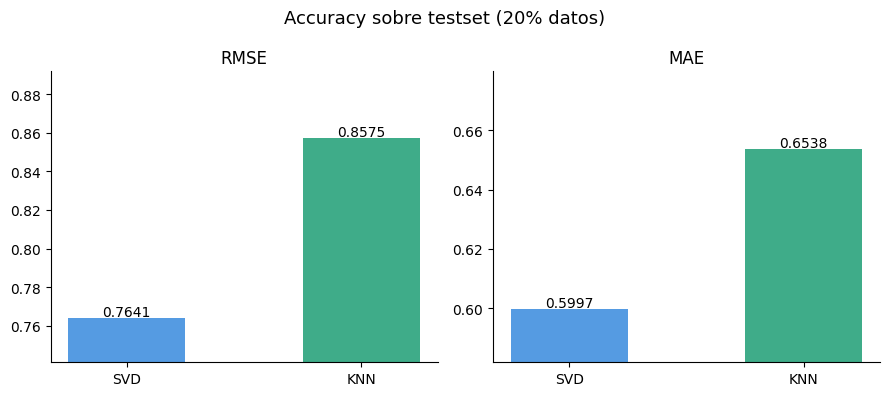

In [34]:
from surprise import accuracy as surp_acc

# Predicciones sobre el testset fijo (ya existe de secciones anteriores)
preds_svd = svd.test(testset)
preds_knn = knn.test(testset)

rmse_svd = surp_acc.rmse(preds_svd, verbose=False)
rmse_knn = surp_acc.rmse(preds_knn, verbose=False)
mae_svd  = surp_acc.mae(preds_svd,  verbose=False)
mae_knn  = surp_acc.mae(preds_knn,  verbose=False)

summary = pd.DataFrame({
    'SVD': {'RMSE': rmse_svd, 'MAE': mae_svd},
    'KNN': {'RMSE': rmse_knn, 'MAE': mae_knn},
}).T.round(4)

display(summary)

# ── Figura 1 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Accuracy sobre testset (20% datos)', fontsize=13)

for ax, vals, title in [
    (axes[0], [rmse_svd, rmse_knn], 'RMSE'),
    (axes[1], [mae_svd,  mae_knn],  'MAE'),
]:
    bars = ax.bar(['SVD', 'KNN'], vals, color=['#378ADD', '#1D9E75'],
                  alpha=0.85, edgecolor='none', width=0.5)
    ax.set_title(title)
    ax.set_ylim(min(vals) * 0.97, max(vals) * 1.04)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + (max(vals)-min(vals))*0.01,
                f'{v:.4f}', ha='center', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_rmse_mae.png', dpi=150, bbox_inches='tight')
plt.show()


MAE, es el promedio de la suma de los errores absolutos, se interpreta como que de media nos estamos equivocando en 0.59-0.60 estrellas. RMSE, tiene en cambio a penaalizar los errores gradndes. 

### 3.2 Error desglosado por rating real

¿Los dos modelos fallan igual en todos los ratings o hay diferencias según si el libro gustó mucho o poco?

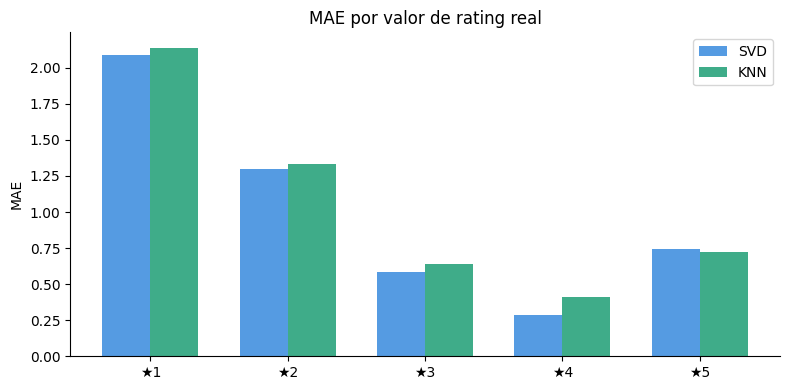

In [36]:
def mae_by_rating(predictions):
    buckets = defaultdict(list)
    for _, _, true_r, est, _ in predictions:
        buckets[int(round(true_r))].append(abs(true_r - est))
    return {r: np.mean(errs) for r, errs in sorted(buckets.items())}

mae_svd_r = mae_by_rating(preds_svd)
mae_knn_r = mae_by_rating(preds_knn)

rating_vals = sorted(set(mae_svd_r) | set(mae_knn_r))
x = np.arange(len(rating_vals))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [mae_svd_r.get(r, 0) for r in rating_vals], w,
       label='SVD', color='#378ADD', alpha=0.85, edgecolor='none')
ax.bar(x + w/2, [mae_knn_r.get(r, 0) for r in rating_vals], w,
       label='KNN', color='#1D9E75', alpha=0.85, edgecolor='none')

ax.set_title('MAE por valor de rating real', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'★{r}' for r in rating_vals])
ax.set_ylabel('MAE')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_mae_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

En error MAE es mas elevado para los ratinf mas bajos.

### 3.3 Métricas de ranking — Precision@K, Recall@K, NDCG@K

El RMSE mide el error de predicción, pero en la práctica lo que importa
es si los libros relevantes aparecen **al principio** de la lista recomendada.

Calculamos las métricas para distintos valores de K (tamaño de la lista de recomendación). Un libro se considera **relevante** si su rating real ≥ 4★.

Hay un **trade-off natural** entre Precision y Recall al aumentar K:
- K pequeño → alta Precision, bajo Recall (lista corta, muy precisa pero incompleta)
- K grande → baja Precision, alto Recall (lista larga, cubre más pero con más ruido)

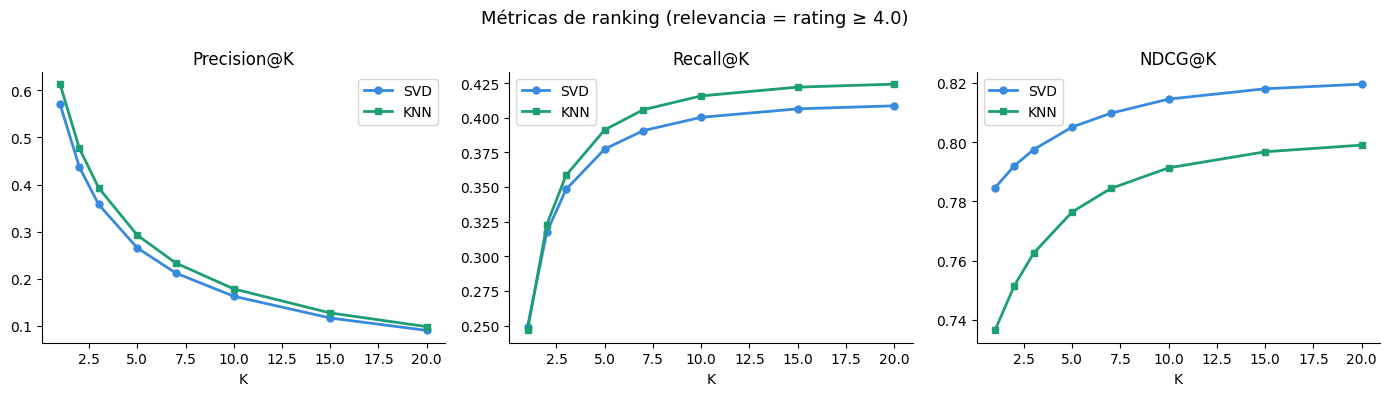

In [37]:
K_VALUES = [1, 2, 3, 5, 7, 10, 15, 20]
THRESHOLD = 4.0  # rating >= 4 → libro "relevante"

def precision_recall_at_k(predictions, k, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precs, recs = [], []
    for ratings in user_est_true.values():
        ratings.sort(reverse=True)
        top_k = ratings[:k]
        n_rel = sum(r >= threshold for _, r in ratings)
        n_hit = sum((e >= threshold) and (r >= threshold) for e, r in top_k)
        precs.append(sum(e >= threshold for e, _ in top_k) / k)
        recs.append(n_hit / n_rel if n_rel > 0 else 0)
    return np.mean(precs), np.mean(recs)

def ndcg_at_k(predictions, k, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    ndcgs = []
    for ratings in user_est_true.values():
        ratings.sort(reverse=True)
        top_k = ratings[:k]
        ideal = sorted([r for _, r in ratings], reverse=True)[:k]
        dcg  = sum((r >= threshold) / np.log2(i + 2) for i, (_, r) in enumerate(top_k))
        idcg = sum((r >= threshold) / np.log2(i + 2) for i, r in enumerate(ideal))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)

metrics = {'SVD': {'prec':[], 'rec':[], 'ndcg':[]},
           'KNN': {'prec':[], 'rec':[], 'ndcg':[]}}

for k in K_VALUES:
    p, r = precision_recall_at_k(preds_svd, k, THRESHOLD)
    metrics['SVD']['prec'].append(p)
    metrics['SVD']['rec'].append(r)
    metrics['SVD']['ndcg'].append(ndcg_at_k(preds_svd, k, THRESHOLD))
    p, r = precision_recall_at_k(preds_knn, k, THRESHOLD)
    metrics['KNN']['prec'].append(p)
    metrics['KNN']['rec'].append(r)
    metrics['KNN']['ndcg'].append(ndcg_at_k(preds_knn, k, THRESHOLD))

# ── Figura 3 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Métricas de ranking (relevancia = rating ≥ {THRESHOLD})', fontsize=13)

for ax, key, title in [
    (axes[0], 'prec', 'Precision@K'),
    (axes[1], 'rec',  'Recall@K'),
    (axes[2], 'ndcg', 'NDCG@K'),
]:
    ax.plot(K_VALUES, metrics['SVD'][key], 'o-', color='#378ADD', label='SVD', lw=2, ms=5)
    ax.plot(K_VALUES, metrics['KNN'][key], 's-', color='#1D9E75', label='KNN', lw=2, ms=5)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


**Precision@K**: toma los K libros con mayor predicción y cuenta qué fracción tiene rating real ≥ 4. Mide la "calidad" de la lista.  
**Recall@K**: de todos los libros que realmente le gustarían al usuario (rating real ≥4), cuenta cuántos han aparecido en el top-K. Mide la "cobertura" de la lista.  
**NDCG@K**:  Normalized Discounted Cumulative Gain. igual que Precision pero ponderando por posición — un libro relevante en posición 1 vale mucho más que en posición 5. Captura si el modelo no solo acierta sino que acierta primero.  


**Precision**. para el caso KNN y k=5, de lo que recomiendo el 30% es bueno   
**Recall**: ewn KNN de todo lo que el usuario considera bueno, el 40% está en la lista top 5 (k=5)

### 3.4 Coverage y long tail

¿Qué fracción del catálogo de libros aparece en recomendaciones?
KNN tiende a recomendar siempre los mismos libros populares (*popularity bias*).

**Item Coverage**: porcentaje del catálogo total que aparece al menos una vez en el top-10 de algún usuario. del total de items del dataset, que porecentaje de ellos aparece en el top10 recomendado a un usuario. A mayor coverage, mayor variedad. 

Un coverage bajo indica **popularity bias**: el modelo recomienda siempre los mismos libros populares, ignorando la *long tail* (libros de nicho que podrían gustar a usuarios específicos).

El gráfico de long tail muestra si las recomendaciones siguen la distribución de popularidad real (gris) o si se dispersan más uniformemente por el catálogo.

In [39]:
def item_coverage(predictions, n_items_total, top_k=10):
    user_preds = defaultdict(list)
    for uid, iid, _, est, _ in predictions:
        user_preds[uid].append((est, iid))
    rec_items = set()
    rec_count = defaultdict(int)
    for up in user_preds.values():
        for _, iid in sorted(up, reverse=True)[:top_k]:
            rec_items.add(iid)
            rec_count[iid] += 1
    return len(rec_items) / n_items_total, rec_count

n_items = trainset.n_items
cov_svd, rc_svd = item_coverage(preds_svd, n_items)
cov_knn, rc_knn = item_coverage(preds_knn, n_items)
print(f"Coverage SVD: {cov_svd:.1%}  |  Coverage KNN: {cov_knn:.1%}")

# Popularidad real de cada libro en el trainset
item_pop = defaultdict(int)
for uid, iid, _ in trainset.all_ratings():
    item_pop[trainset.to_raw_iid(iid)] += 1
sorted_items = sorted(item_pop, key=item_pop.get, reverse=True)
pop_arr = np.array([item_pop[i] for i in sorted_items], dtype=float)

def rec_curve(rc, sorted_items):
    arr = np.array([rc.get(i, 0) for i in sorted_items], dtype=float)
    return arr / arr.max() if arr.max() > 0 else arr

Coverage SVD: 98.7%  |  Coverage KNN: 98.5%


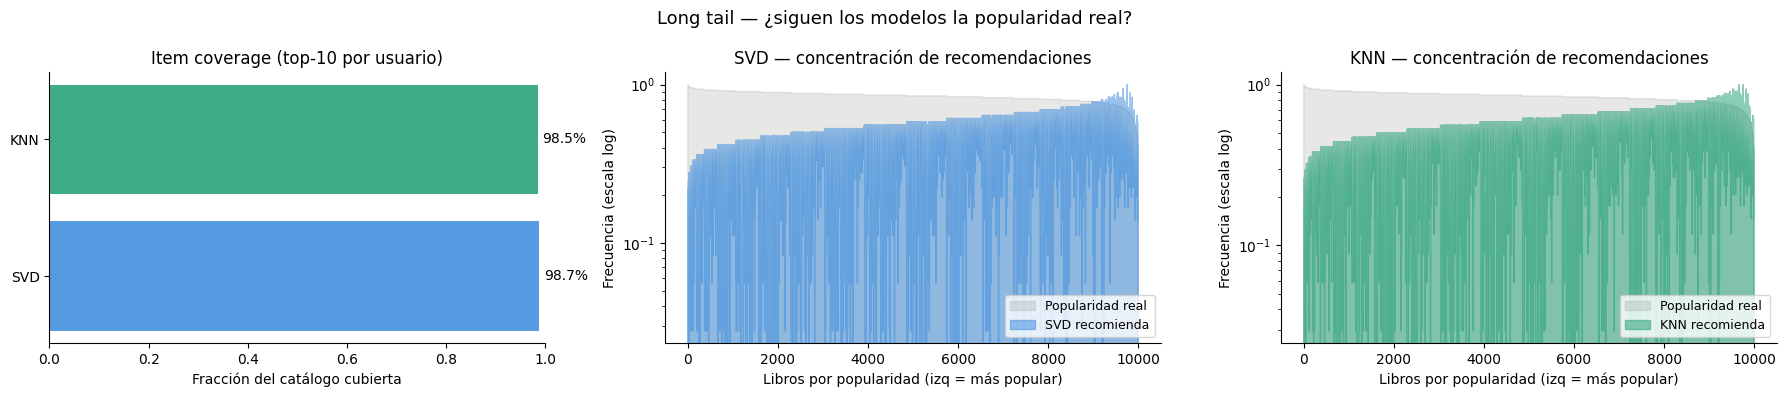

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Gráfico 1: Coverage barras (igual que antes) ─────────────────────
bars = axes[0].barh(['SVD', 'KNN'], [cov_svd, cov_knn],
                    color=['#378ADD', '#1D9E75'], alpha=0.85, edgecolor='none')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Fracción del catálogo cubierta')
axes[0].set_title('Item coverage (top-10 por usuario)')
for bar, v in zip(bars, [cov_svd, cov_knn]):
    axes[0].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

x_idx   = np.arange(len(sorted_items))
pop_norm = pop_arr / pop_arr.max()

# ── Gráfico 2: SVD vs popularidad real ───────────────────────────────
axes[1].fill_between(x_idx, pop_norm,
                     alpha=0.2, color='#888780', label='Popularidad real')
axes[1].fill_between(x_idx, rec_curve(rc_svd, sorted_items),
                     alpha=0.5, color='#378ADD', label='SVD recomienda')
axes[1].set_yscale('log')                          # ← escala log
axes[1].set_title('SVD — concentración de recomendaciones')
axes[1].set_xlabel('Libros por popularidad (izq = más popular)')
axes[1].set_ylabel('Frecuencia (escala log)')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Gráfico 3: KNN vs popularidad real ───────────────────────────────
axes[2].fill_between(x_idx, pop_norm,
                     alpha=0.2, color='#888780', label='Popularidad real')
axes[2].fill_between(x_idx, rec_curve(rc_knn, sorted_items),
                     alpha=0.5, color='#1D9E75', label='KNN recomienda')
axes[2].set_yscale('log')                          # ← escala log
axes[2].set_title('KNN — concentración de recomendaciones')
axes[2].set_xlabel('Libros por popularidad (izq = más popular)')
axes[2].set_ylabel('Frecuencia (escala log)')
axes[2].legend(fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Long tail — ¿siguen los modelos la popularidad real?', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

Coverage: quiere decir que el el 98% de los libros está recibiendo alguna recomendación dentroi del top10 de cada usuario.   

No siguen poularity, si lo siguieran su curva sería muy parecida a la GRIS

### 3.5 Tiempo de inferencia

SVD predice consultando solo los vectores latentes ya calculados.
KNN tiene que buscar vecinos en cada predicción, lo que lo hace más lento en producción.

SVD predice en O(1) por par (usuario, libro): solo hace un producto escalar entre dos vectores de 100 dimensiones ya calculados.

KNN tiene que calcular similitudes con los K vecinos más cercanos en cada predicción, lo que lo hace significativamente más lento — especialmente relevante en sistemas de producción con millones de usuarios.

SVD: 1060.7 ms para 1000 predicciones  (1.06 ms/pred)
KNN: 3389.2 ms para 1000 predicciones  (3.39 ms/pred)


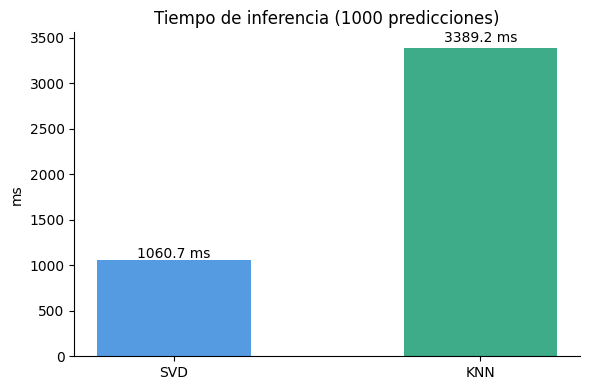

In [41]:
N = 1000
sample = testset[:N]

t0 = time.perf_counter(); svd.test(sample); t_svd = (time.perf_counter()-t0)*1000
t0 = time.perf_counter(); knn.test(sample); t_knn = (time.perf_counter()-t0)*1000

print(f"SVD: {t_svd:.1f} ms para {N} predicciones  ({t_svd/N:.2f} ms/pred)")
print(f"KNN: {t_knn:.1f} ms para {N} predicciones  ({t_knn/N:.2f} ms/pred)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['SVD', 'KNN'], [t_svd, t_knn],
              color=['#378ADD', '#1D9E75'], alpha=0.85, edgecolor='none', width=0.5)
ax.set_title(f'Tiempo de inferencia ({N} predicciones)')
ax.set_ylabel('ms')
for bar, v in zip(bars, [t_svd, t_knn]):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.02,
            f'{v:.1f} ms', ha='center', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_timing.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 Resumen: accuracy vs. diversidad

El modelo ideal tendría bajo RMSE (eje Y, invertido) **y** alta cobertura del catálogo (eje X).
En la práctica hay que elegir según el caso de uso.

El gráfico posiciona cada modelo en el espacio **accuracy vs. diversidad**:

- **Eje X** (Coverage): mayor = más diverso, recomienda más libros distintos
- **Eje Y** (RMSE, invertido): más arriba = más preciso

El modelo ideal estaría arriba a la derecha. En la práctica:
- **SVD** tiende a ser más preciso y más diverso (factores latentes capturan preferencias individuales)
- **KNN** tiende a tener popularity bias (recomienda lo que muchos usuarios similares valoraron)

> **¿Cuál elegir?** Depende del caso de uso. Si el objetivo es precisión → SVD. Si el objetivo es descubrimiento de libros de nicho → explorar modelos híbridos o añadir regularización de diversidad.

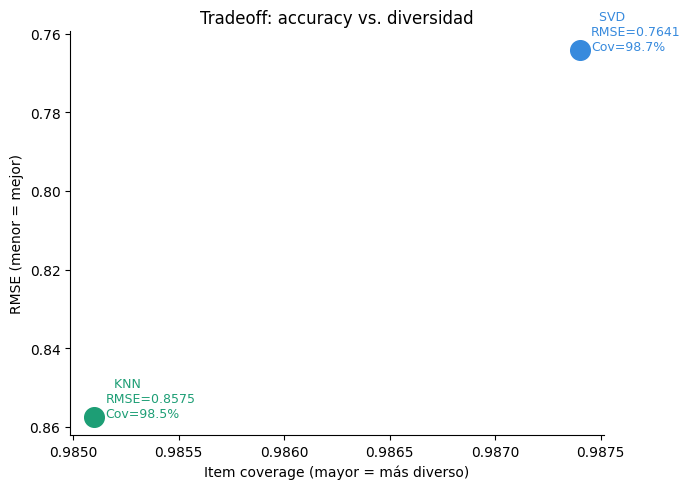

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, rmse, cov, color in [
    ('SVD', rmse_svd, cov_svd, '#378ADD'),
    ('KNN', rmse_knn, cov_knn, '#1D9E75'),
]:
    ax.scatter(cov, rmse, s=200, color=color, zorder=3)
    ax.annotate(f'  {name}\nRMSE={rmse:.4f}\nCov={cov:.1%}',
                (cov, rmse), fontsize=9, color=color,
                xytext=(8, 0), textcoords='offset points')

ax.set_xlabel('Item coverage (mayor = más diverso)')
ax.set_ylabel('RMSE (menor = mejor)')
ax.set_title('Tradeoff: accuracy vs. diversidad')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
